<a href="https://colab.research.google.com/github/Rebidex/IRA2_proiect_cercetare/blob/main/Proiect_IRA2_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proiect: Optimizarea Eficienței Energetice în Clădirile Inteligente (UTCN Living Lab)

**Obiectivele principale:**
1. Curățarea datelor brute de la senzorii BEMS.
2. Identificarea echipamentelor mari folosind tehnici NILM (Non-Intrusive Load Monitoring).
3. Pregătirea datelor pentru predicția consumului (Feature Engineering).
4. Extragerea datelor externe (Electricity Maps / Transelectrica).
5. Simularea unor strategii de eficientizare: Load Shifting și reutilizarea căldurii (Data Center Heat Reuse).

## Încărcarea Datelor
Se vor importa bibliotecile necesare și se va încărca setul de date primit (`.csv`), setând coloana de timp ca index pentru a facilita analiza seriilor de timp (Time Series).

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cale_fisier = '/content/Consum FTP Server 2017-2026.xlsx'

try:
    print("Se incarca fisierul.:P")
    df = pd.read_excel(cale_fisier)

    df.columns = df.columns.str.strip()

    df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    df = df.dropna(subset=['Date'])
    df.set_index('Date', inplace=True)

    # FILTRARE (Concept Drift): Păstrăm doar datele incepând cu 2019
    # Motiv: Clădirile au fost reabilitate, iar datele mai vechi nu mai reprezintă realitatea fizică curentă.
    df = df[df.index >= '2019-01-01']

    print("Fișierul a fost încărcat cu succes! Primele rânduri:")
    display(df.head())

except Exception as e:
    print(f"A apărut o eroare la încărcarea fișierului: {e}")

Se incarca fisierul.:P
Fișierul a fost încărcat cu succes! Primele rânduri:


,ID_11,ID_12,ID_13,ID_14,ID_21,ID_22,ID_23,ID_24,ID_31,ID_32,...,NoOutlier_ID_13,NoOutlier_ID_14,NoOutlier_ID_21,NoOutlier_ID_22,NoOutlier_ID_23,NoOutlier_ID_24,NoOutlier_ID_31,NoOutlier_ID_32,NoOutlier_ID_41,NoOutlier_ID_42
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:05:45,21.838,9.499,1.716,0.0,11.252,0.0,3.577,4.883,2.927,0.02,...,1.716,0.0,11.252,0.0,3.577,4.883,2.927,0.02,4.550,0.0
2019-01-01 00:20:45,21.466,9.455,1.748,0.0,11.669,0.0,3.532,4.955,3.126,0.02,...,1.748,0.0,11.669,0.0,3.532,4.955,3.126,0.02,4.541,0.0
2019-01-01 00:35:45,21.522,9.399,1.553,0.0,10.699,0.0,3.456,4.892,3.136,0.02,...,1.553,0.0,10.699,0.0,3.456,4.892,3.136,0.02,4.453,0.0
2019-01-01 00:50:45,21.576,9.459,1.537,0.0,10.719,0.0,3.524,4.231,3.012,0.02,...,1.537,0.0,10.719,0.0,3.524,4.231,3.012,0.02,4.462,0.0
2019-01-01 01:05:45,21.393,9.164,1.563,0.0,10.177,0.0,3.474,4.176,2.892,0.02,...,1.563,0.0,10.177,0.0,3.474,4.176,2.892,0.02,4.483,0.0


## Curățarea Datelor și Calculul Consumului Auxiliar
Senzorii pot înregistra valori aberante (outliers) din cauza erorilor de comunicație.
* Se va aplica un filtru (Thresholding): valorile sub 0 kW și peste 2000 kW vor fi eliminate (NaN) și interpolate liniar.
* Se va calcula consumul auxiliar estimat pentru Clădire Baritiu și Instalatii scăzând consumatorii cunoscuți din consumul general.


In [68]:
# totate id-urile pe care trebuie sa le curatam
toate_id_urile = ['ID_11', 'ID_12', 'ID_13', 'ID_14', 'ID_21', 'ID_22',
                  'ID_23', 'ID_24', 'ID_31', 'ID_32', 'ID_41', 'ID_42']

# eliminare outlieri
for contor in toate_id_urile:
    if contor in df.columns:
        df.loc[(df[contor] > 2000) | (df[contor] < 0), contor] = np.nan

#  calcul consum auxiliar
if all(col in df.columns for col in ['ID_11', 'ID_12', 'ID_13', 'ID_14']):
    df['Auxiliar_B'] = df['ID_11'] - df[['ID_12', 'ID_13', 'ID_14']].sum(axis=1)
    df['Auxiliar_B'] = df['Auxiliar_B'].clip(lower=0)

if all(col in df.columns for col in ['ID_31', 'ID_32']):
    df['Auxiliar_I'] = df['ID_31'] - df['ID_32']
    df['Auxiliar_I'] = df['Auxiliar_I'].clip(lower=0)

print("Datele au fost curățate, iar consumul auxiliar a fost calculat.")

Datele au fost curățate, iar consumul auxiliar a fost calculat.


## Repararea Continuității Seriei de Timp
Setul de date prezintă intervale de timp cu date lipsă (gap-uri), ceea ce fragmentează vizualizările și perturbă algoritmii.
Am reeșantionat datele la o frecvență fixă de 15 minute (`15T`) și am interpolat liniar valorile lipsă pentru a restabili continuitatea curbelor de sarcină.

In [69]:
# o înregistrare fixă la fiecare 15 minute
df = df.resample('15T').mean()

#interpolarea gap-urilor
df = df.interpolate(method='time')

# umplere posibile goluri
df = df.bfill().ffill()

print("Seria de timp a fost reesantionată la 15 min. Curbele sunt acum continue.")

Seria de timp a fost reesantionată la 15 min. Curbele sunt acum continue.


## Ingineria Caracteristicilor: Integrarea Contextului Academic și Pandemiei
Pentru ca modelul de predicție să fie precis, am oferit cateva "contexte". Consumul universității nu este dictat doar de temperatură, ci și de prezența fizică a studenților.
În această secțiune adăugăm:
1. **Calendarul Academic**: Bazat pe structura anilor universitari din 2017-2026, am clasificat fiecare zi ca fiind de Cursuri, Sesiune sau Vacanță.
2. **Sesiunea de Toamnă**: Am marcat prima săptămână din septembrie pentru examenele de restanțe.
3. **Eticheta COVID-19**: Este de luat în cosiderare perioada de cursuri online (martie 2020 - octombrie 2021) pentru a izola această anomalie istorică.

In [70]:
import numpy as np


df['Ora'] = df.index.hour
df['Ziua_Saptamanii'] = df.index.dayofweek
df['Luna'] = df.index.month
df['Este_Weekend'] = df['Ziua_Saptamanii'].apply(lambda x: 1 if x >= 5 else 0)
# Eticheta pentru Pandemie
df['Este_Pandemie_Online'] = np.where((df.index >= '2020-03-15') & (df.index < '2021-10-01'), 1, 0)

# Structura anului universitar
def clasifica_perioada_utcn(data):
    luna, ziua = data.month, data.day

    # Sesiunea de toamnă
    if luna == 9 and ziua <= 7: return 'Sesiune'
    # Vacanța de vară
    if luna in [7, 8] or (luna == 9 and ziua > 7): return 'Vacanta'
    # Vacanța de iarnă
    if (luna == 12 and ziua >= 21) or (luna == 1 and ziua <= 5): return 'Vacanta'
    # Sesiunea de iarnă
    if (luna == 1 and ziua >= 15) or (luna == 2 and ziua <= 10): return 'Sesiune'
    # Vacanța intersemestrială
    if luna == 2 and 11 <= ziua <= 18: return 'Vacanta'
    # Sesiunea de vară
    if luna == 6: return 'Sesiune'

    return 'Cursuri'

df['Tip_Perioada'] = df.index.map(clasifica_perioada_utcn)

# One-hot Enconding pentru convertirea categoriilor in numere
df = pd.get_dummies(df, columns=['Tip_Perioada'])
for col in [c for c in df.columns if 'Tip_Perioada_' in c]:
    df[col] = df[col].astype(int)

print("Contextul academic și eticheta COVID au fost integrate cu succes.")

Contextul academic și eticheta COVID au fost integrate cu succes.


## Monitorizarea Non-Intruzivă a Sarcinii (NILM)
Scopul NILM este de a identifica funcționarea echipamentelor individuale (cum sunt chillerele) folosind doar datele de la contorul general.
Am folosit datele de la sub-contoarele Chillerelor (ex: `ID_32` pentru Instalații) pentru a stabili momentele în care acestea sunt pornite. Datele vor servi drept "Ground Truth" pentru a antrena algoritmul să recunoască semnătura energetică a chillerului în consumul general (`ID_31`).

Vârful de consum al chiller-ului a fost la: 2023-07-28 13:00:00


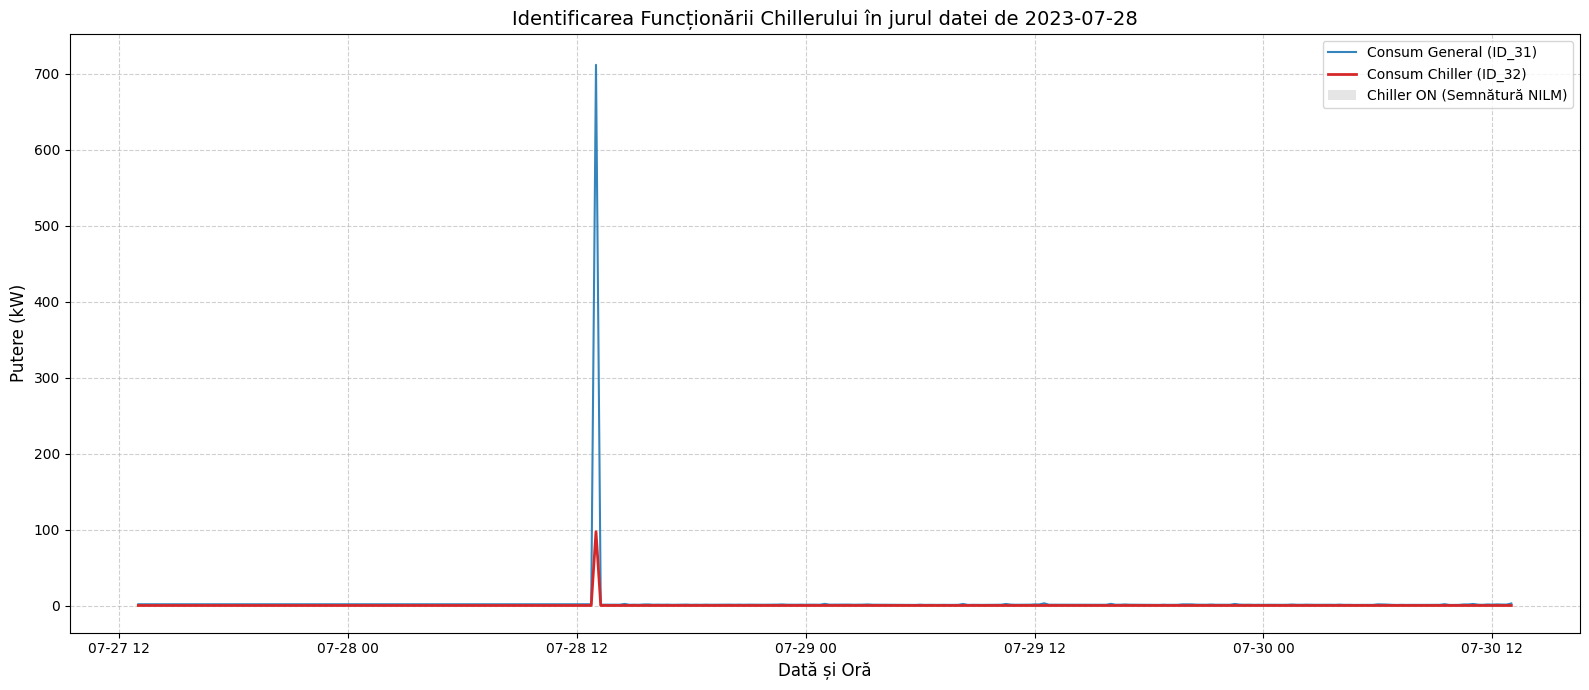

In [71]:
import pandas as pd

# 1. Găsim momentul în care Chiller-ul a avut consumul MAXIM
moment_maxim = df['ID_32'].idxmax()
print(f"Vârful de consum al chiller-ului a fost la: {moment_maxim}")

# Definirea stării de activitate a Chiller-ului ('Chiller_C_Activ')
# Considerăm chiller-ul PORNIT (1) dacă consumul său (ID_32) este mai mare de 5 kW, altfel OPRIT (0).
if 'ID_32' in df.columns:
    df['Chiller_C_Activ'] = (df['ID_32'] > 5).astype(int)

# 2. Creăm o fereastră de 3 zile în jurul acelui moment
# (Luăm o zi înainte și două după pentru a vedea frumos curba)
data_start = moment_maxim - pd.Timedelta(days=1)
data_stop = moment_maxim + pd.Timedelta(days=2)

fereastra_viz = df.loc[data_start:data_stop]

plt.figure(figsize=(16, 7))

# Plotăm consumul general și cel al chillerului
plt.plot(fereastra_viz.index, fereastra_viz['ID_31'], label='Consum General (ID_31)', color='tab:blue', alpha=0.9, linewidth=1.5)
plt.plot(fereastra_viz.index, fereastra_viz['ID_32'], label='Consum Chiller (ID_32)', color='tab:red', linewidth=2)

# Evidențiem funcționarea Chillerului
plt.fill_between(fereastra_viz.index, 0, fereastra_viz['ID_31'].max() + 5,
                 where=fereastra_viz['Chiller_C_Activ'] == 1,
                 facecolor='gray', alpha=0.2, label='Chiller ON (Semnătură NILM)')

plt.title(f'Identificarea Funcționării Chillerului în jurul datei de {moment_maxim.strftime("%Y-%m-%d")}', fontsize=14)
plt.ylabel('Putere (kW)', fontsize=12)
plt.xlabel('Dată și Oră', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Analiză Comparativă: Impactul Pandemiei (Online) vs. Revenirea la Normal (Fizic)
Pentru a înțelege cât de mult influențează prezența studenților consumul energetic, am comparat aceeași fereastră calendaristică (luna Aprilie) în doi ani diferiți:
1. **Aprilie 2020**: Perioadă de lockdown total, cursuri exclusiv online. Clădirea funcționează în regim de "bază" (doar echipamente critice).
2. **Aprilie 2022**: Revenire completă la prezența fizică în campus.
Această comparație ne permite să izolăm "Baseline-ul" clădirii (consumul minim necesar pentru a menține serverele și sistemele de pază active) de "Consumul Operațional" (lumini, prize, climatizare pentru oameni).

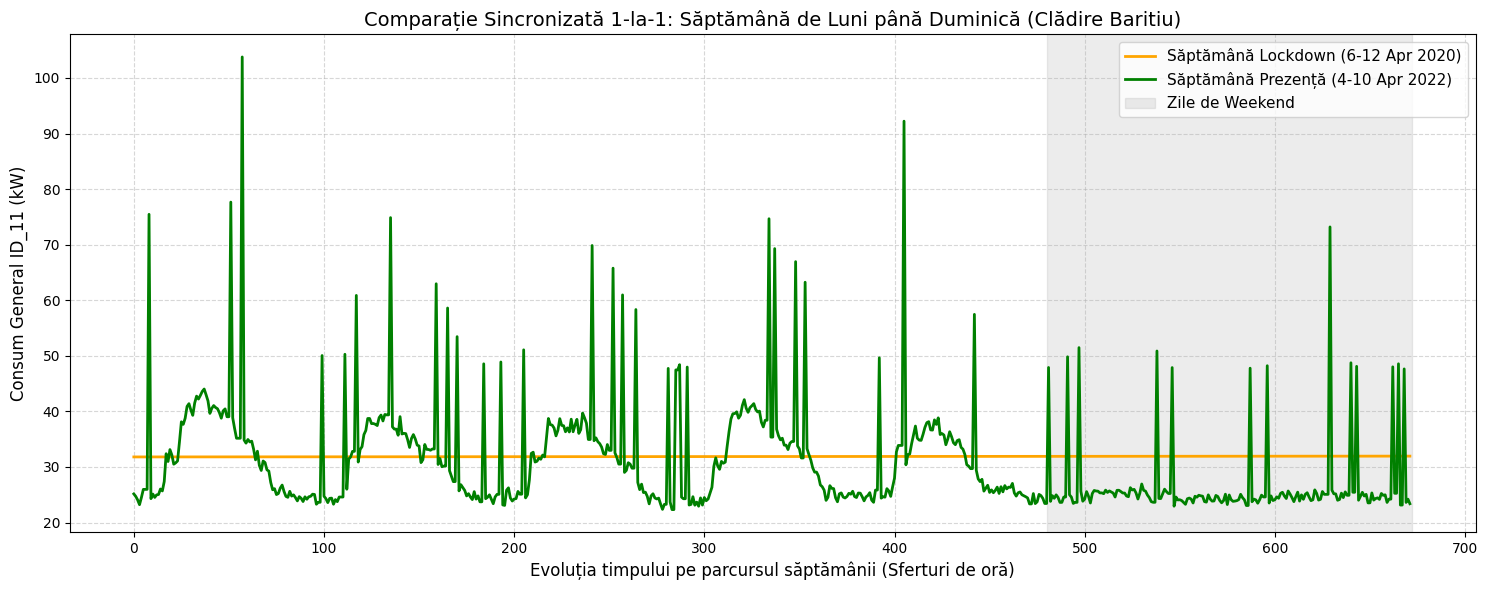

In [72]:

sapt_2020_Baritiu = df.loc['2020-04-06 00:00':'2020-04-12 23:45'].copy()
sapt_2022_Baritiu = df.loc['2022-04-04 00:00':'2022-04-10 23:45'].copy()

# (O săptămână perfectă are 7 zile * 24 ore * 4 sferturi = 672 puncte)
lungime_minima = min(len(sapt_2020_Baritiu), len(sapt_2022_Baritiu))

y_2020 = sapt_2020_Baritiu['ID_11'].values[:lungime_minima]
y_2022 = sapt_2022_Baritiu['ID_11'].values[:lungime_minima]
axa_x = range(lungime_minima)

plt.figure(figsize=(15, 6))

# plotarea curbelor
plt.plot(axa_x, y_2020, label='Săptămână Lockdown (6-12 Apr 2020)', color='orange', linewidth=2)
plt.plot(axa_x, y_2022, label='Săptămână Prezență (4-10 Apr 2022)', color='green', linewidth=2)

plt.title('Comparație Sincronizată 1-la-1: Săptămână de Luni până Duminică (Clădire Baritiu)', fontsize=14)
plt.ylabel('Consum General ID_11 (kW)', fontsize=12)
plt.xlabel('Evoluția timpului pe parcursul săptămânii (Sferturi de oră)', fontsize=12)

# zona de Weekend (ultimele 2 zile = ultimele 192 de sferturi de oră)
inceput_weekend = lungime_minima - 192
if inceput_weekend > 0:
    plt.axvspan(inceput_weekend, lungime_minima, color='gray', alpha=0.15, label='Zile de Weekend')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

## Se etichetează Datele pentru NILM (Non-Intrusive Load Monitoring)
Pentru a antrena un algoritm care să detecteze echipamentele mari doar din consumul general (`ID_31`), este nevoie să se stabilească momentele clare în care chiller-ul a funcționat.
Se folosesc datele sub-contorului `ID_32` (Chiller Clădirea Instalatii) ca "Ground Truth" pentru a eticheta starea (ON/OFF).

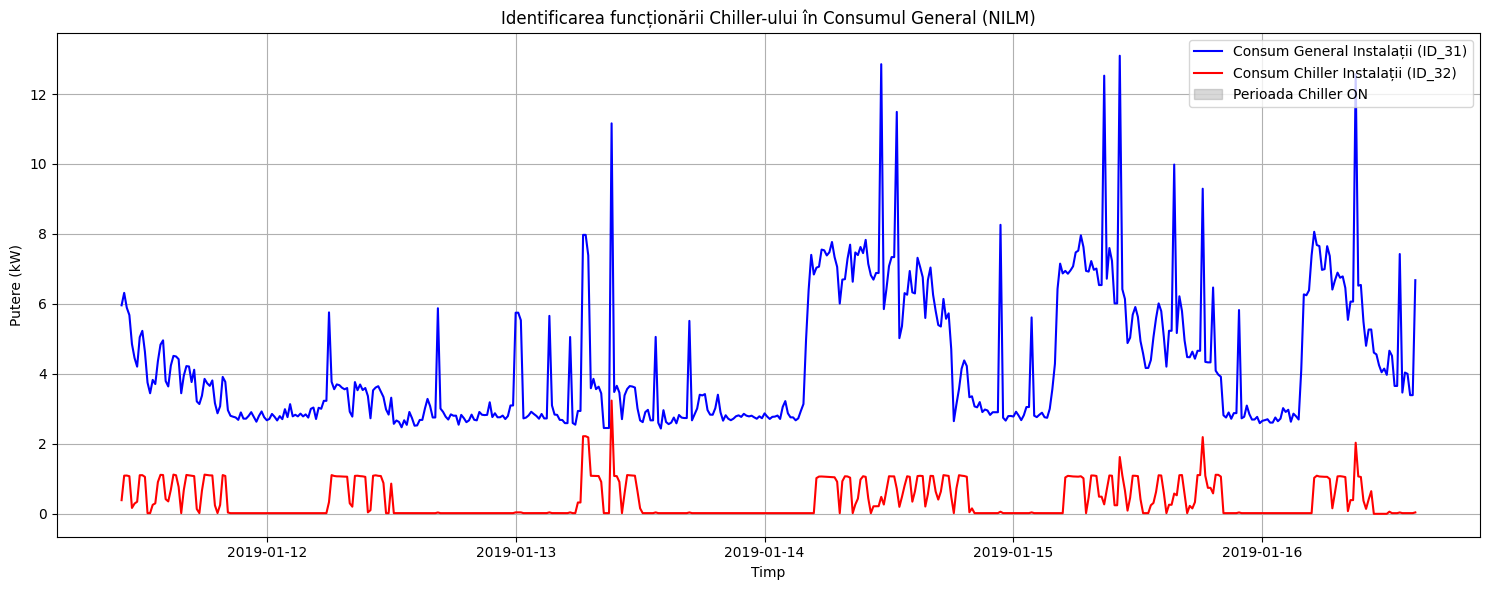

In [73]:
if 'ID_32' in df.columns and 'ID_31' in df.columns:
    # dacă se consumă mai mult de 5 kW, considerăm chiller-ul PORNIT (1), altfel OPRIT (0)
    df['Chiller_I_Status'] = (df['ID_32'] > 5).astype(int)

    fereastra = df.dropna().iloc[1000:1500]

    plt.figure(figsize=(15, 6))

    # Consumul general
    plt.plot(fereastra.index, fereastra['ID_31'], label='Consum General Instalații (ID_31)', color='blue')
    # Consumul izolat al Chiller-ului
    plt.plot(fereastra.index, fereastra['ID_32'], label='Consum Chiller Instalații (ID_32)', color='red')

    # Se evidențiează perioadele de funcționare
    plt.fill_between(fereastra.index, 0, fereastra['ID_31'].max(),
                     where=fereastra['Chiller_I_Status']==1,
                     color='gray', alpha=0.3, label='Perioada Chiller ON')

    plt.title('Identificarea funcționării Chiller-ului în Consumul General (NILM)')
    plt.xlabel('Timp')
    plt.ylabel('Putere (kW)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Se extrag Caracteristicile pentru Machine Learning (Feature Engineering)
Consumul unei clădiri este puternic influențat de sezonalitate și programul de lucru uman. Pentru viitoarele modele de predicție, trebuie să se extragă componentele de timp din indexul Datetime.

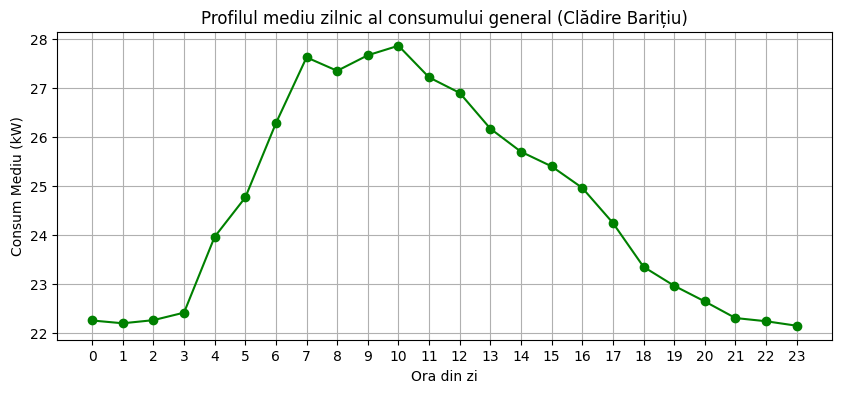

In [74]:
# ora, ziua, luna din index
df['Ora'] = df.index.hour
df['Ziua_Saptamanii'] = df.index.dayofweek # 0 = Luni, 6 = Duminică
df['Luna'] = df.index.month

# weekend sau nu
df['Este_Weekend'] = df['Ziua_Saptamanii'].apply(lambda x: 1 if x >= 5 else 0)

# profilul de consum orar pentru Clădire Barițiu
if 'ID_11' in df.columns:
    consum_mediu_orar = df.groupby('Ora')['ID_11'].mean()

    plt.figure(figsize=(10, 4))
    plt.plot(consum_mediu_orar.index, consum_mediu_orar.values, marker='o', color='green')
    plt.title('Profilul mediu zilnic al consumului general (Clădire Barițiu)')
    plt.xlabel('Ora din zi')
    plt.ylabel('Consum Mediu (kW)')
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.show()

## Se extrag Datele Externe (Electricity Maps API)
Pentru strategiile de optimizare ("Load Shifting"), este nevoie de vizibilitate asupra rețelei naționale (SEN). Se face conectarea la API-ul Electricity Maps pentru a putea prelua prognoza prețurilor sau a intensității carbonului.

In [75]:
import requests
import pandas as pd

API_KEY = 'rnm6KCcaehsYdQEjaZhe'

def obtine_date_retea(api_key, zona='RO'):
    # Se folosește API-ul pentru a cere prognoza intensității emisiilor de carbon pentru România
    url = f"https://api.electricitymap.org/v3/carbon-intensity/forecast?zone={zona}"
    headers = {"auth-token": api_key}

    try:
        response = requests.get(url, headers=headers)

        if response.status_code == 200:
            date_api = response.json()
            prognoza_df = pd.DataFrame(date_api['forecast'])
            prognoza_df['datetime'] = pd.to_datetime(prognoza_df['datetime'])
            prognoza_df.set_index('datetime', inplace=True)
            return prognoza_df
        else:
            print(f"Eroare API. Cod de status: {response.status_code}. (Verifică dacă cheia API este corectă!)")
            return None

    except Exception as e:
        print(f"Eroare la conexiunea API: {e}")
        return None

date_retea = obtine_date_retea(API_KEY)

if date_retea is not None:
    print("Datele de pe Electricity Maps au fost descărcate cu succes!")
    display(date_retea.head())

Datele de pe Electricity Maps au fost descărcate cu succes!


,carbonIntensity
datetime,
2026-04-18 17:00:00+00:00,177
2026-04-18 18:00:00+00:00,161
2026-04-18 19:00:00+00:00,138
2026-04-18 20:00:00+00:00,194
2026-04-18 21:00:00+00:00,224


## Concepte de Optimizare: Load Shifting și Heat Reuse
Se definesc funcțiile logice prin care algoritmul AI va lua decizii în timp real:
1. **Load Shifting:** Decalarea funcționării HVAC pentru a evita orele cu energie scumpă.
2. **Heat Reuse:** Evaluarea cantității de căldură disipată de Data Center (`ID_12`) pentru a reduce sarcina Centralei Termice (`ID_22`).

In [76]:
def strategia_load_shifting(ora, pret_energie_estimat, temp_clasa):
    """
    Mai jos apare o logică de bază pentru Load Shifting.
    (Scheletele va fi înlocuit de partea cu Machine Learning)
    """
    PRET_MARE = 500
    PRET_MIC = 200

    if pret_energie_estimat >= PRET_MARE and temp_clasa < 25:
        # dacă e vârf de sarcină, dar clădirea e deja răcoroasă, oprim consumatorul
        return "OFF (Shifted)"
    elif pret_energie_estimat <= PRET_MIC and 12 <= ora <= 16:
        # pre-răcire când energia e ieftină/verde
        return "ON (Pre-Cooling)"
    else:
        return "AUTO (Termostat)"

def calcul_reutilizare_caldura(consum_servere_kw):
    """
    1 kW consumat de echipamentele IT generează aprox. 1 kW de căldură disipată.
    Returnează câtă energie poate fi redusă teoretic de la centrala termică.
    """
    EFICIENTA_RECUPERARE = 0.8 # Se presupune că 80% din aerul cald poate fi captat
    caldura_recuperata_kw = consum_servere_kw * EFICIENTA_RECUPERARE
    return caldura_recuperata_kw

# Exemplu de test folosind o valoare de la ID_12/servere
if 'ID_12' in df.columns:
    consum_servere_mediu = df['ID_12'].mean()
    caldura_salvata = calcul_reutilizare_caldura(consum_servere_mediu)
    print(f"La un consum mediu al serverelor de {consum_servere_mediu:.2f} kW,")
    print(f"se pot recupera aprox. {caldura_salvata:.2f} kW putere termică.")

La un consum mediu al serverelor de 12.27 kW,
se pot recupera aprox. 9.82 kW putere termică.
